In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.ticker as ticker
from math import log

In [2]:
data = pd.read_excel("Data.xlsx")

In [5]:
r22=data["R t22"]
q22=data["Q t22"]

r30=data["R t30"]
q30=data["Q t30"]

r40=data["R t40"]
q40=data["Q t40"]

r50=data["R t50"]
q50=data["Q t50"]

r60=data["R t60"]
q60=data["Q t60"]

r70=data["R t70"]
q70=data["Q t70"]

In [6]:
dt = [[q22, r22], [q30, r30], [q40, r40], [q50, r50], [q60, r60], [q70, r70]]

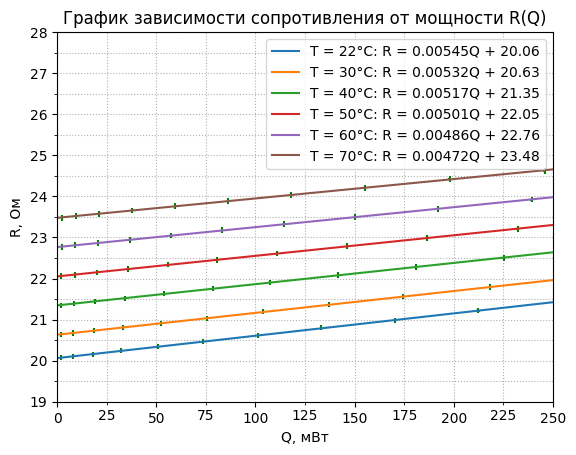

In [27]:
Rt=[]
dRdQ=[]
T=[22, 30, 40, 50, 60, 70]
ax = plt.gca()
def apr(dat):
    global dRdQ
    global Rt
    global T
    global i
    coeffs = np.polyfit(dat[0], dat[1], deg=1)
    poly_func = np.poly1d(coeffs)
    x = np.linspace(0, 250, 2000)
    y = poly_func(x)
    Rt.append(coeffs[1])
    dRdQ.append(coeffs[0])
    plt.errorbar(dat[0], dat[1], yerr=list(map(lambda x: x*0.003, dat[1])),xerr=list(map(lambda x: x*0.003, dat[0])), ecolor='green', color='none')
    plt.plot(x, y, label=f"T = {T[i]}°C: R = {coeffs[0]:.5f}Q + {coeffs[1]:.2f}")

ax.set_xlim(0, 250)
ax.set_ylim(19, 28)
for i in range(6):
    apr(dt[i])
ax.legend()
ax.xaxis.set_minor_locator(ticker.MultipleLocator(25))  
ax.yaxis.set_minor_locator(ticker.MultipleLocator(0.5))
ax.xaxis.set_minor_formatter(ticker.FormatStrFormatter('%g'))
ax.grid(True, which='both', axis='both', linestyle='dotted')
plt.title("График зависимости сопротивления от мощности R(Q)")
plt.xlabel("Q, мВт")
plt.ylabel("R, Ом")
plt.show()
Rt=list(map(float, Rt))
dRdQ=list(map(float, dRdQ))

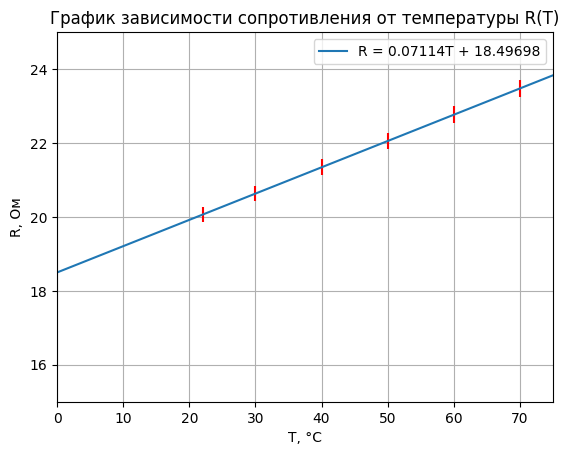

0.07113897454645864
[0.005446856156698685, 0.0053219322541879785, 0.005174053376793744, 0.005012266371837811, 0.004861846617865872, 0.004720764906548795]


In [29]:
T=[22, 30, 40, 50, 60, 70]
# Аппроксимация полиномом 2-й степени
coeffs = np.polyfit(T, Rt, deg=1)
poly_func = np.poly1d(coeffs) #превращает найденные коэффициенты в полиномиальную функцию, которую можно использовать как обычную

# Генерация линии аппроксимации
x_fit = np.linspace(0, 75, 200)
y_fit = poly_func(x_fit)
ax = plt.gca()
ax.set_xlim(0, 75)
ax.set_ylim(15, 25)
plt.errorbar(T, Rt, yerr=list(map(lambda x: x*0.01, Rt)), ecolor='red', color='none')
plt.plot(x_fit, y_fit, label=f"R = {coeffs[0]:.5f}T + {coeffs[1]:.5f}")
plt.legend()
plt.xlabel("T, °C")
plt.ylabel("R, Ом")
plt.title("График зависимости сопротивления от температуры R(T)")
plt.grid(True)
plt.show()
a=float(coeffs[0])
print(a)
print(dRdQ)

In [30]:
c=0.1398747145
Kt=[]
for i in range(6):
    Kt.append(c/dRdQ[i])
print(Kt)

[25.679898729834903, 26.282693544234547, 27.03387543842416, 27.90648064634146, 28.769873978747317, 29.62967173094372]


In [31]:
lnK=list(map(log, Kt))
lnT=list(map(lambda x:log(x+273), T))
print(lnK)
print(lnT)

[3.24570853527173, 3.268910682437103, 3.297090725461473, 3.3288589430850886, 3.3593287972531094, 3.388776282581939]
[5.68697535633982, 5.713732805509369, 5.746203190540153, 5.777652323222656, 5.808142489980444, 5.8377304471659395]


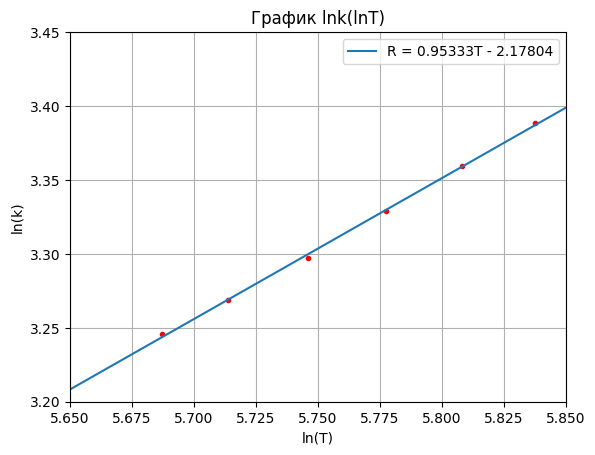

In [33]:
coeffs = np.polyfit(lnT, lnK, deg=1)
poly_func = np.poly1d(coeffs) #превращает найденные коэффициенты в полиномиальную функцию, которую можно использовать как обычную

# Генерация линии аппроксимации
x_fit = np.linspace(5, 6, 200)
y_fit = poly_func(x_fit)
ax = plt.gca()
ax.set_xlim(5.65, 5.85)
ax.set_ylim(3.2, 3.45)
plt.scatter(lnT, lnK, marker='.', linewidths=1, color='red')
plt.plot(x_fit, y_fit, label=f"R = {coeffs[0]:.5f}T - {abs(coeffs[1]):.5f}")
plt.legend()
plt.xlabel("ln(T)")
plt.ylabel("ln(k)")
plt.title("График lnk(lnT)")
plt.grid(True)
plt.show()